# Import Library

In [1]:
import emoji
import pandas as pd
import re
from rule_7 import retain_allowed_symbols
import ast
import numpy as np
import string

# Import Dataset

In [2]:
dataset = pd.read_csv("data_with_true_label_fixed.csv", encoding='utf-8-sig')
dataset

,post_shortcode,post_date,commenter_username,comment_text,comment_likes,true_aspect_1,true_aspect_2,true_sentiment,type
0,DFKccJJPeW_,23/01/2025 09:32,tiara_180319,Pemasangan baru tidak ada kelanjutan setelah s...,0,Pemasangan,Pelayanan,Negatif,Pernyataan
1,DFKccJJPeW_,23/01/2025 09:32,dshellysss,Sama naik semua ini juga komplen..biasanya cum...,0,Harga,Harga,Negatif,Pernyataan
2,DFKccJJPeW_,23/01/2025 09:32,shicya_cute,Min kalau puteran PDAM dol itu sya ngadu kesia...,0,Meteran (Macet/Bermasalah),Meteran (Macet/Bermasalah),Netral,Pertanyaan
3,DFKccJJPeW_,23/01/2025 09:32,iirmawulan,Denda PDAM telat ngalah2in pinjol 50k jadi 150...,1,Harga,Harga,Negatif,Pernyataan
4,DFKccJJPeW_,23/01/2025 09:32,aini_al_aydrus,Air ya klo pagi dan jam 3 sore kenapa selalu mati,1,Air Tidak Mengalir,Air Tidak Mengalir,Negatif,Pertanyaan
...,...,...,...,...,...,...,...,...,...
743,DGe2WlxPbvn,25/02/2025 04:15,mell0dz,gunung anyar tambak apa juga terdampak yaa kok...,1,Air Tidak Mengalir,Air Tidak Mengalir,Netral,Pertanyaan
744,DGe2WlxPbvn,25/02/2025 04:15,dodo_hd12,"Hasilnya gimana, min @pdamsuryasembada ??",1,Lainnya,Lainnya,Netral,Pertanyaan
745,DGcY2FIPTcc,24/02/2025 05:20,adiguna2022,min. daerah sidodadi ada pipa besar bocor. moh...,1,Kebocoran,Kebocoran,Negatif,Pernyataan
746,DGZ7MuDvXk3,23/02/2025 06:22,nikelu22,Min. Ini pdam saya mati sekitar tgl segini. Sa...,0,Air Tidak Mengalir,Pelayanan,Netral,Pertanyaan


In [3]:
new_data = pd.read_csv("new_data.csv", encoding='utf-8-sig')
new_data

,comment_text,true_aspect_1,true_aspect_2,true_sentiment,type
0,Ini greges baru mati airnya,Air Tidak Mengalir,Air Tidak Mengalir,Negatif,Pernyataan
1,Air PDAM hari ini sabtu 22 Juni 2024 daerah pe...,Air Tidak Mengalir,Air Tidak Mengalir,Negatif,Pertanyaan
2,ini mati lagi airnya daerah Krembangan. Semala...,Air Tidak Mengalir,Air Tidak Mengalir,Negatif,Pertanyaan
3,Wilayah Kemayoran juga mati dari kemarin,Air Tidak Mengalir,Air Tidak Mengalir,Negatif,Pernyataan
4,TEGALSARI KEDUNGDORO MATI DARI KEMARIN .. MAU ...,Air Tidak Mengalir,Air Tidak Mengalir,Negatif,Pertanyaan
...,...,...,...,...,...
1099,Siip👍,Lainnya,Lainnya,Positif,Pernyataan
1100,Sip,Lainnya,Lainnya,Positif,Pernyataan
1101,Alhamdulillah barokah,Lainnya,Lainnya,Positif,Pernyataan
1102,Keren👏👏👏👍🏻👍🏻👍🏻,Lainnya,Lainnya,Positif,Pernyataan


# Merging Data

In [4]:
# Drop kolom yang tidak diperlukan
dataset = dataset.drop(columns=[
    "post_shortcode",
    "post_date",
    "commenter_username",
    "comment_likes"
])
# Gabungkan dataset dan new_data
df = pd.concat([dataset, new_data], ignore_index=True)
df.to_csv("combined_data.csv", index=False, encoding='utf-8-sig')
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1852 entries, 0 to 1851
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   comment_text    1852 non-null   object
 1   true_aspect_1   1852 non-null   object
 2   true_aspect_2   1852 non-null   object
 3   true_sentiment  1852 non-null   object
 4   type            1852 non-null   object
dtypes: object(5)
memory usage: 72.5+ KB


,comment_text,true_aspect_1,true_aspect_2,true_sentiment,type
0,Pemasangan baru tidak ada kelanjutan setelah s...,Pemasangan,Pelayanan,Negatif,Pernyataan
1,Sama naik semua ini juga komplen..biasanya cum...,Harga,Harga,Negatif,Pernyataan
2,Min kalau puteran PDAM dol itu sya ngadu kesia...,Meteran (Macet/Bermasalah),Meteran (Macet/Bermasalah),Netral,Pertanyaan
3,Denda PDAM telat ngalah2in pinjol 50k jadi 150...,Harga,Harga,Negatif,Pernyataan
4,Air ya klo pagi dan jam 3 sore kenapa selalu mati,Air Tidak Mengalir,Air Tidak Mengalir,Negatif,Pertanyaan


# Removing Duplicates

In [5]:
df.duplicated().sum()

np.int64(161)

In [6]:
df = df.drop_duplicates()
df = df.reset_index(drop=True)
df.duplicated().sum()

np.int64(0)

# Preparing Emoji Dataset

In [7]:
df_emoji = pd.read_csv('emoji.csv', index_col=0)

In [8]:
# Ganti spasi dengan underscore pada kolom 'name'
df_emoji['name'] = df_emoji['name'].str.replace(' ', '_')
df_emoji['name'] = df_emoji['name'].str.replace('-', '_')
df_emoji['name'] = df_emoji['name'].str.replace('⊛_', '')
df_emoji['name'] = df_emoji['name'].str.replace('"', '')
df_emoji['name'] = df_emoji['name'].str.replace(':', '')
df_emoji['name'] = df_emoji['name'].str.replace(',', '')
df_emoji['name'] = df_emoji['name'].str.replace("'", "")
# Tampilkan 5 baris pertama untuk memastikan hasilnya
print(df_emoji.head())

                              name
0                    grinning_face
1      grinning_face_with_big_eyes
2  grinning_face_with_smiling_eyes
3   beaming_face_with_smiling_eyes
4          grinning_squinting_face


In [9]:
df_emoji.to_csv('emoji_underscore.csv', index=True)

In [10]:
df_emoji

,name
0,grinning_face
1,grinning_face_with_big_eyes
2,grinning_face_with_smiling_eyes
3,beaming_face_with_smiling_eyes
4,grinning_squinting_face
...,...
1811,flag_Zambia
1812,flag_Zimbabwe
1813,flag_England
1814,flag_Scotland


# Cleansing

In [11]:
import pandas as pd
import re

# --- 1. Baca daftar emoji dari file emoji_underscore.csv ---
emoji_df = pd.read_csv('emoji_underscore.csv')
emoji_df['name'] = emoji_df['name'].astype(str).str.strip()

# Buat pola regex berdasarkan nama emoji (format :emoji_name:)
emoji_names = [re.escape(name) for name in emoji_df['name'] if name]
emoji_pattern = re.compile(r':(' + '|'.join(emoji_names) + r'):', flags=re.IGNORECASE)


# --- 2. Fungsi pembersihan teks ---
def clean_text(text):
    
    if pd.isna(text):
        return ''
    
    text = str(text).lower()

    # =========================================
    # Hapus emoji
    # =========================================
    text = emoji_pattern.sub('', text)

    # =========================================
    # Hapus URL
    # =========================================
    text = re.sub(r'http\S+|www.\S+', '', text)

    # =========================================
    # Hapus tanda hubung "-"
    # =========================================
    text = re.sub('-', ' ', text)

    # =========================================
    # Hapus mention dan hashtag
    # =========================================
    text = re.sub(r'@\w+|#\w+', '', text)

    # =========================================
    # Hapus angka
    # =========================================
    text = re.sub(r'\d+', '', text)

    # =========================================
    # Hapus karakter selain huruf dan . , ! ?
    # =========================================
    text = retain_allowed_symbols(text)

    # =========================================
    # Hapus duplikasi punctuation
    # =========================================
    text = re.sub(r"\.{2,}", " . ", text)
    text = re.sub(r"\,{2,}", " , ", text)
    text = re.sub(r"\!{2,}", " ! ", text)
    text = re.sub(r"\?{2,}", " ? ", text)

    # =========================================
    # Hapus spasi berlebih
    # =========================================
    text = re.sub(r'\s+', ' ', text).strip()

    # =========================================
    # Tambahkan spasi sebelum dan sesudah punctuation (. , ! ?)
    # =========================================
    text = re.sub(r'([.,!?])', r' \1 ', text)

    # =========================================
    # Hapus punctuation tertentu (kecuali . , ! ?)
    # =========================================
    text = re.sub(r"[`~@#$%^&*()_+={}\[\]\\\/<>\":;]", " ", text)

    return text


# Terapkan fungsi clean_text ke kolom comment_text
df['cleaned_text'] = df['comment_text'].apply(clean_text)


# --- 4. Hapus baris kosong ---
before = len(df)
df = df[df['cleaned_text'].str.strip().astype(bool)]
after = len(df)

print(f"🧹 {before - after} baris dihapus karena hanya berisi emoji atau kosong.")

🧹 27 baris dihapus karena hanya berisi emoji atau kosong.


In [12]:
print(df['cleaned_text'].to_markdown())

|      | cleaned_text                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                              |
|-----:|:------------------------------------------------------------------------------------------

# Stopword Removal + Normalization

In [13]:
import nltk
import ast
import string
import pandas as pd
from nltk.tokenize import word_tokenize

# Pastikan tokenizer tersedia
nltk.download('punkt', quiet=True)

# --- Load stopwords ---
with open("combined_stop_words.txt", "r", encoding="utf-8") as f:
    stop_words = f.read().splitlines()

# --- Load slang dictionary ---
with open("update_combined_slang_words.txt", "r", encoding="utf-8") as f:
    slang_words = ast.literal_eval(f.read())


# =========================================================
# Punctuation yang ingin dipertahankan
# =========================================================
keep_punctuation = {".", ",", "!", "?"}


# --- Fungsi Stopword Removal + Slang Formalization ---
def formalize_text(text):

    if pd.isna(text) or not isinstance(text, str):
        return ""

    # Tokenisasi sementara
    tokens = word_tokenize(text.lower())

    # Slang formalization
    normalized_tokens = [slang_words.get(w, w) for w in tokens]

    # Stopword removal (kecuali punctuation tertentu)
    filtered_tokens = [
        w for w in normalized_tokens
        if (
            w not in stop_words and
            (w not in string.punctuation or w in keep_punctuation) and
            w.strip()
        )
    ]

    # Gabungkan kembali menjadi teks
    return " ".join(filtered_tokens)


# Terapkan pada cleaned_text
df['normalized_text'] = df['cleaned_text'].apply(formalize_text)

print(df[['cleaned_text', 'normalized_text']].head().to_markdown())

|    | cleaned_text                                                                                                                           | normalized_text                                                                                                                   |
|---:|:---------------------------------------------------------------------------------------------------------------------------------------|:----------------------------------------------------------------------------------------------------------------------------------|
|  0 | pemasangan baru tidak ada kelanjutan setelah survey . katanya bisa komplain cs lewat wa . sedangkan di wa gak ada tanggapan  .         | pemasangan tidak ada kelanjutan survey . katanya komplain pelayanan pelanggan whatsapp . sedangkan whatsapp tidak ada tanggapan . |
|  1 | sama naik semua ini juga komplen  .  biasanya cuma an sekrang an  .  duh semua serba membayar to jadi g percaya sama pemerintah begini | naik komplain . an sekarang 

# Drop Empty row

In [14]:
# --- Hapus baris dengan normalized_text kosong ---
before = len(df)

df = df[
    df['normalized_text'].notna() & 
    (df['normalized_text'].astype(str).str.strip() != "")
]

after = len(df)

print("✅ Baris kosong pada kolom 'normalized_text' berhasil dihapus.")
print(f"🗑️ Total baris dihapus: {before - after}")

# Simpan dataset
# df.to_csv("cleaned_normalized_dataset.csv", index=False, encoding='utf-8-sig')

✅ Baris kosong pada kolom 'normalized_text' berhasil dihapus.
🗑️ Total baris dihapus: 3


# Segmentasi Teks

In [15]:
import pandas as pd
import re

# =========================================================
# 1️⃣ LOAD LIST KONJUNGSI
# =========================================================

with open("augmentation_text_dict.txt", "r", encoding="utf-8") as f:
    conjunctions = [line.strip().lower() for line in f if line.strip()]

# contoh isi file
# sedang
# lalu
# tapi
# karena
# tetapi
# padahal
# akan


# =========================================================
# 2️⃣ FUNGSI SPLIT BERDASARKAN KONJUNGSI
# =========================================================

def split_by_conjunction(text):

    if pd.isna(text) or not isinstance(text, str):
        return pd.Series(["", ""])

    text_lower = text.lower()

    for conj in conjunctions:

        # cari konjungsi sebagai kata utuh
        pattern = r'\b' + re.escape(conj) + r'\b'
        match = re.search(pattern, text_lower)

        if match:
            idx = match.start()

            sentence_1 = text[:idx].strip()
            sentence_2 = text[idx:].strip()

            return pd.Series([sentence_1, sentence_2])

    # jika tidak ada konjungsi
    return pd.Series([text.strip(), ""])


# =========================================================
# 3️⃣ APLIKASI KE DATAFRAME
# =========================================================

df[['sentence_1', 'sentence_2']] = df['normalized_text'].apply(split_by_conjunction)


# =========================================================
# 4️⃣ HASIL
# =========================================================

print(df[['normalized_text', 'sentence_1', 'sentence_2']].head())

# simpan dataset
# df.to_csv("data_with_augmented_sentences.csv", index=False, encoding='utf-8-sig')

                                     normalized_text  \
0  pemasangan tidak ada kelanjutan survey . katan...   
1  naik komplain . an sekarang an . aduh serba me...   
2            admin keran pdam rusak mengadu ke siapa   
3      denda pdam terlambat mengalahkan pinjol parah   
4                      air pagi jam sore selalu mati   

                                          sentence_1  \
0  pemasangan tidak ada kelanjutan survey . katan...   
1  naik komplain . an sekarang an . aduh serba me...   
2            admin keran pdam rusak mengadu ke siapa   
3      denda pdam terlambat mengalahkan pinjol parah   
4                      air pagi jam sore selalu mati   

                                 sentence_2  
0  sedangkan whatsapp tidak ada tanggapan .  
1                                            
2                                            
3                                            
4                                            


# Tokenization

In [16]:
from nltk.tokenize import word_tokenize
import pandas as pd
import re

# =========================================================
# FUNGSI TOKENIZATION
# =========================================================

def tokenize_text(text):
    
    if pd.isna(text) or not isinstance(text, str) or text.strip() == "":
        return []
    
    # =====================================================
    # Pisahkan punctuation menjadi token tersendiri
    # =====================================================
    text = re.sub(r'([.,!?])', r' \1 ', text)
    
    # Hapus spasi berlebih
    text = re.sub(r'\s+', ' ', text).strip()
    
    # Tokenisasi
    return word_tokenize(text)


# =========================================================
# TOKENIZATION PADA 3 KOLOM
# =========================================================

df['tokens_normalized'] = df['normalized_text'].apply(tokenize_text)

df['tokens_sentence_1'] = df['sentence_1'].apply(tokenize_text)

df['tokens_sentence_2'] = df['sentence_2'].apply(tokenize_text)


# =========================================================
# HASIL
# =========================================================

print(
    df[
        [
            'normalized_text',
            'sentence_1',
            'sentence_2',
            'tokens_normalized',
            'tokens_sentence_1',
            'tokens_sentence_2'
        ]
    ].head().to_markdown()
)

# df.to_csv("data_with_tokenized_sentences.csv", index=False, encoding='utf-8-sig')

|    | normalized_text                                                                                                                   | sentence_1                                                                               | sentence_2                               | tokens_normalized                                                                                                                                                                        | tokens_sentence_1                                                                                                             | tokens_sentence_2                                           |
|---:|:----------------------------------------------------------------------------------------------------------------------------------|:-----------------------------------------------------------------------------------------|:-----------------------------------------|:-----------------------------------------------------------------------------

# Stemming

In [ ]:
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

# =========================================================
# 1️⃣ INISIALISASI STEMMER
# =========================================================

factory = StemmerFactory()
stemmer = factory.create_stemmer()


# =========================================================
# 2️⃣ FUNGSI STEMMING
# =========================================================

def stem_tokens(tokens):

    keep_punctuation = {'.', ',', '?', '!'}

    if isinstance(tokens, str):
        tokens = tokenize_text(tokens)

    if not isinstance(tokens, list):
        return ""

    stemmed_tokens = []

    for token in tokens:
        if token in keep_punctuation:
            stemmed_tokens.append(token)
        else:
            stemmed_tokens.append(stemmer.stem(token))

    return " ".join(stemmed_tokens)


# =========================================================
# 3️⃣ STEMMING PADA SETIAP KOLOM TOKEN
# =========================================================

df['stemmed_normalized'] = df['tokens_normalized'].apply(stem_tokens)

df['stemmed_sentence_1'] = df['tokens_sentence_1'].apply(stem_tokens)

df['stemmed_sentence_2'] = df['tokens_sentence_2'].apply(stem_tokens)


# =========================================================
# 4️⃣ HASIL
# =========================================================

print(
    df[
        [
            'tokens_normalized',
            'tokens_sentence_1',
            'tokens_sentence_2',
            'stemmed_normalized',
            'stemmed_sentence_1',
            'stemmed_sentence_2'
        ]
    ].head().to_markdown()
)


# =========================================================
# 5️⃣ SIMPAN DATASET
# =========================================================

# df[
#     [
#         'comment_text',
#         'cleaned_text',
#         'normalized_text',
#         'true_aspect_1',
#         'true_aspect_2',
#         'true_sentiment',
#         'type',
#         'sentence_1',
#         'sentence_2',
#         'tokens_normalized',
#         'tokens_sentence_1',
#         'tokens_sentence_2',
#         'stemmed_normalized',
#         'stemmed_sentence_1',
#         'stemmed_sentence_2'
#     ]
# ].to_csv("final_stemmed_dataset.csv", index=False, encoding='utf-8-sig')

|    | tokens_normalized                                                                                                                                                                        | tokens_sentence_1                                                                                                             | tokens_sentence_2                                           | stemmed_normalized                                                                                          | stemmed_sentence_1                                                        | stemmed_sentence_2                  |
|---:|:-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|:------------------------------------------------------------------------------------------------------------------------------|:------------------------------------------------------------|:--------

# Train: Not Segmented Data | Test: 100% Data

In [18]:
df_test = df

# Mengambil data yang nilai sentence_2 kosong (NaN atau string kosong)
df_train = df[df['sentence_2'].isna() | (df['sentence_2'].str.strip() == '')]
df_train = df_train.drop(columns=['sentence_1', 'sentence_2', 'tokens_sentence_1', 'tokens_sentence_2', 'stemmed_sentence_1', 'stemmed_sentence_2'])
# Reset index agar rapi
df_train = df_train.reset_index(drop=True)

# Menampilkan hasil
print(df_train)
df_train.to_csv("train_data.csv", index=False, encoding='utf-8-sig')

                                           comment_text  \
0     Sama naik semua ini juga komplen..biasanya cum...   
1     Min kalau puteran PDAM dol itu sya ngadu kesia...   
2     Denda PDAM telat ngalah2in pinjol 50k jadi 150...   
3     Air ya klo pagi dan jam 3 sore kenapa selalu mati   
4     gimana si, udah menghubungi layanan pengaduan ...   
...                                                 ...   
1357                                         Nice info!   
1358                                              Siip👍   
1359                                                Sip   
1360                              Alhamdulillah barokah   
1361                                     Keren👏👏👏👍🏻👍🏻👍🏻   

                   true_aspect_1               true_aspect_2 true_sentiment  \
0                          Harga                       Harga        Negatif   
1     Meteran (Macet/Bermasalah)  Meteran (Macet/Bermasalah)         Netral   
2                          Harga                      

# Feature Extraction & Multi Aspect Based Classification

In [19]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# =========================================================
# 1️⃣ VECTORISASI TF-IDF (TRAIN DATA)
# Train menggunakan stemmed_normalized
# =========================================================

vectorizer = TfidfVectorizer(
    ngram_range=(1,2),
    min_df=2
)

X_train = vectorizer.fit_transform(df_train['stemmed_normalized'])

train_aspects = df_train['true_aspect_1'].to_numpy()


# =========================================================
# 2️⃣ FUNGSI PREDIKSI ASPEK
# =========================================================

THRESHOLD = 0.3

def predict_aspect(text):

    if pd.isna(text) or str(text).strip() == "":
        return "Lainnya", 0

    X_test = vectorizer.transform([text])

    sims = cosine_similarity(X_test, X_train)[0]

    best_idx = sims.argmax()
    best_score = sims[best_idx]
    best_aspect = train_aspects[best_idx]

    if best_score < THRESHOLD:
        return "Lainnya", best_score

    return best_aspect, best_score


# =========================================================
# 3️⃣ MULTI-ASPECT CLASSIFICATION
# =========================================================

predicted_aspects = []
similarity_scores = []

for i,row in df_test.iterrows():

    text1 = row['stemmed_sentence_1']
    text2 = row['stemmed_sentence_2']

    # ----------------------------------
    # ASPECT KALIMAT 1
    # ----------------------------------
    aspect1, score1 = predict_aspect(text1)

    # ----------------------------------
    # ASPECT KALIMAT 2
    # ----------------------------------
    if pd.isna(text2) or str(text2).strip()=="":
        aspect2 = aspect1
        score2 = score1
    else:
        aspect2, score2 = predict_aspect(text2)

    # ----------------------------------
    # GABUNGKAN ASPEK (SELALU 2 ASPEK)
    # ----------------------------------
    final_aspect = f"{aspect1} | {aspect2}"

    final_score = max(score1,score2)

    predicted_aspects.append(final_aspect)
    similarity_scores.append(final_score)

    # =====================================================
    # DEBUG PRINT
    # =====================================================
    print("="*80)
    print("Index :",i)
    print("Sentence 1 :",text1)
    print("Sentence 2 :",text2)
    print("Predicted :",final_aspect)
    print("Score 1 :",round(score1,4))
    print("Score 2 :",round(score2,4))
    print("="*80,"\n")


# =========================================================
# 4️⃣ SIMPAN HASIL
# =========================================================

df_test['predicted_aspects'] = predicted_aspects
df_test['similarity_scores'] = similarity_scores


output_cols = [
'comment_text',
'cleaned_text',
'normalized_text',
'stemmed_sentence_1',
'stemmed_sentence_2',
'true_aspect_1',
'true_aspect_2',
'true_sentiment',
'type',
'predicted_aspects',
'similarity_scores'
]


df_test[output_cols].to_csv(
"trial_multi_aspect_classification_result.csv",
index=False,
encoding="utf-8-sig"
)

print("✅ Multi-aspect classification selesai")

Index : 0
Sentence 1 : pasang tidak ada lanjut survey . kata komplain layan langgan whatsapp .
Sentence 2 : sedang whatsapp tidak ada tanggap .
Predicted : Pelayanan | Pelayanan
Score 1 : 0.3658
Score 2 : 0.5321

Index : 1
Sentence 1 : naik komplain . an sekarang an . aduh serba bayar kan ga percaya perintah
Sentence 2 : 
Predicted : Harga | Harga
Score 1 : 1.0
Score 2 : 1.0

Index : 2
Sentence 1 : admin keran pdam rusak adu ke siapa
Sentence 2 : 
Predicted : Meteran (Macet/Bermasalah) | Meteran (Macet/Bermasalah)
Score 1 : 1.0
Score 2 : 1.0

Index : 3
Sentence 1 : denda pdam lambat kalah pinjol parah
Sentence 2 : 
Predicted : Harga | Harga
Score 1 : 1.0
Score 2 : 1.0

Index : 4
Sentence 1 : air pagi jam sore selalu mati
Sentence 2 : 
Predicted : Air Tidak Mengalir | Air Tidak Mengalir
Score 1 : 1.0
Score 2 : 1.0

Index : 5
Sentence 1 : si , sudah hubung layan adu sudah hampir minggu tidak ada tindak !
Sentence 2 : 
Predicted : Pelayanan | Pelayanan
Score 1 : 1.0
Score 2 : 1.0

Index :

# Multi Aspect Based Evaluation

In [20]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# =========================================================
# 1️⃣ BENTUK SET TRUE ASPECT (MULTI)
# =========================================================

def build_true_aspect_set(row):

    aspects = set()

    if pd.notna(row['true_aspect_1']) and row['true_aspect_1'] != 'Lainnya':
        aspects.add(row['true_aspect_1'])

    if pd.notna(row['true_aspect_2']) and row['true_aspect_2'] != 'Lainnya':
        aspects.add(row['true_aspect_2'])

    if len(aspects) == 0:
        aspects.add('Lainnya')

    return aspects


df_test['true_aspects_set'] = df_test.apply(build_true_aspect_set, axis=1)


# =========================================================
# 2️⃣ BENTUK SET PREDICTED ASPECT
# =========================================================

def build_predicted_aspect_set(pred):

    if pd.isna(pred) or pred == 'Lainnya':
        return {'Lainnya'}

    return set([a.strip() for a in pred.split('|')])


df_test['predicted_aspects_set'] = df_test['predicted_aspects'].apply(build_predicted_aspect_set)


print(f"Total Data Train : {len(df_train)}")
print(f"Total Data Test  : {len(df_test)}")


# =========================================================
# 3️⃣ EVALUASI MULTI-ASPECT
# =========================================================

# Exact Match
df_test['exact_match'] = (
    df_test['true_aspects_set'] == df_test['predicted_aspects_set']
)

exact_accuracy = df_test['exact_match'].mean()


# Partial Match
df_test['partial_match'] = df_test.apply(
    lambda x: len(x['true_aspects_set'].intersection(x['predicted_aspects_set'])) > 0,
    axis=1
)

partial_accuracy = df_test['partial_match'].mean()


print("\n==============================")
print("🎯 EVALUASI MULTI-ASPECT")
print("==============================")
print(f"Exact Match Accuracy   : {exact_accuracy:.4f}")
print(f"Partial Match Accuracy : {partial_accuracy:.4f}")


# =========================================================
# 4️⃣ STATISTIK PREDICTED ASPECT
# =========================================================

aspect_stats = (
    df_test
    .groupby('predicted_aspects')
    .agg(
        Jumlah_Kemunculan=('predicted_aspects','count'),
        Rata_rata_Similarity=('similarity_scores','mean')
    )
    .reset_index()
    .sort_values('Jumlah_Kemunculan', ascending=False)
)

print("\n===========================================")
print("📊 Statistik Predicted Aspect (Test Data)")
print("===========================================")
print(aspect_stats.to_markdown(index=False))


# =========================================================
# 5️⃣ DISTRIBUSI TRUE ASPECT (MULTI)
# =========================================================

true_aspect_exploded = (
    df_test['true_aspects_set']
    .apply(list)
    .explode()
    .value_counts()
    .reset_index()
)

true_aspect_exploded.columns = ['Aspek','Jumlah']


print("\n==================================================")
print("📌 Distribusi True Aspect (Multi-Aspect)")
print("==================================================")
print(true_aspect_exploded.to_markdown(index=False))


# =========================================================
# 6️⃣ TOTAL SALAH & BENAR
# =========================================================

total_correct = df_test['exact_match'].sum()
total_wrong   = len(df_test) - total_correct


print("\n===========================================")
print("❌ HASIL KLASIFIKASI MULTI-ASPECT")
print("===========================================")
print(f"Total Data Test        : {len(df_test)}")
print(f"Prediksi Benar (Exact) : {total_correct}")
print(f"Prediksi Salah         : {total_wrong}")
print(f"Error Rate             : {total_wrong/len(df_test)*100:.2f}%")


# =========================================================
# 7️⃣ DATA SALAH PREDIKSI
# =========================================================

misclassified_df = df_test.loc[
    ~df_test['exact_match'],
    [
        'comment_text',
        'stemmed_normalized',
        'stemmed_sentence_1',
        'stemmed_sentence_2',
        'true_aspect_1',
        'true_aspect_2',
        'true_aspects_set',
        'predicted_aspects_set',
        'similarity_scores'
    ]
]

misclassified_df.to_csv(
    "trial_misclassified_multi_aspect_data.csv",
    index=False,
    encoding='utf-8-sig'
)

print("\n✅ Evaluasi multi-aspect selesai")

Total Data Train : 1362
Total Data Test  : 1661

🎯 EVALUASI MULTI-ASPECT
Exact Match Accuracy   : 0.8573
Partial Match Accuracy : 0.9591

📊 Statistik Predicted Aspect (Test Data)
| predicted_aspects                                       |   Jumlah_Kemunculan |   Rata_rata_Similarity |
|:--------------------------------------------------------|--------------------:|-----------------------:|
| Lainnya | Lainnya                                       |                 640 |               0.932055 |
| Air Tidak Mengalir | Air Tidak Mengalir                 |                 322 |               0.976312 |
| Meteran (Macet/Bermasalah) | Meteran (Macet/Bermasalah) |                 129 |               0.982099 |
| Harga | Harga                                           |                 107 |               0.962578 |
| Pemasangan | Pemasangan                                 |                  86 |               0.989149 |
| Pelayanan | Pelayanan                                   |             

# Sentiment Analysis Using Rule Based (12 Rules)

In [21]:
# =========================================================
# SENTIMENT ANALYSIS USING RULE BASED (12 RULES)
# =========================================================

from rule_1 import apply_rule_1
from rule_2 import apply_rule_2
from rule_3 import apply_rule_3
from rule_4 import apply_rule_4
from rule_5 import apply_rule_5
from rule_6 import apply_rule_6
from rule_7 import apply_rule_7
from rule_8 import apply_rule_8
from rule_9 import apply_rule_9
from rule_10 import apply_rule_10
from rule_11 import apply_rule_11
from rule_12 import apply_rule_12


def score_to_label(score):
    if score > 0:
        return 'Positif'
    if score < 0:
        return 'Negatif'
    return 'Netral'


df = apply_rule_1(df, token_column='tokens_normalized')
df = apply_rule_2(df, token_column='tokens_normalized')
df = apply_rule_3(df, token_column='tokens_normalized')
df = apply_rule_4(df, token_column='tokens_normalized')
df = apply_rule_5(df, token_column='tokens_normalized')
df = apply_rule_6(df, token_column='tokens_normalized')
df['rule_7_cleaned_text'] = apply_rule_7(df['comment_text']).str.lower().str.replace(r'\s+', ' ', regex=True).str.strip()
df = apply_rule_8(df, text_column='normalized_text')
df = apply_rule_9(df, token_column='tokens_normalized')
df = apply_rule_10(df, text_column='normalized_text')
df = apply_rule_11(df, token_column='tokens_normalized')
df = apply_rule_12(df, text_column='normalized_text')

sentiment_score_columns = [
    'rule_1_sentiment_value',
    'rule_2_sentiment_value',
    'rule_3_sentiment_value',
    'rule_4_sentiment_value',
    'rule_5_sentiment_value',
    'rule_6_sentiment_value',
    'rule_10_sentiment_value',
    'rule_12_sentiment_value',
]

applied_rule_columns = [
    ('Rule 1', 'rule_1_applied'),
    ('Rule 2', 'rule_2_applied'),
    ('Rule 3', 'rule_3_applied'),
    ('Rule 4', 'rule_4_applied'),
    ('Rule 5', 'rule_5_applied'),
    ('Rule 6', 'rule_6_applied'),
    ('Rule 10', 'rule_10_applied'),
    ('Rule 12', 'rule_12_applied'),
]

df['final_sentiment_score'] = df[sentiment_score_columns].fillna(0).sum(axis=1)
df['final_sentiment_label'] = df['final_sentiment_score'].apply(score_to_label)
df['matched_rules'] = df.apply(
    lambda row: ' | '.join(rule_name for rule_name, col_name in applied_rule_columns if bool(row[col_name])),
    axis=1
)

print(df[[
    'comment_text',
    'true_sentiment',
    'final_sentiment_score',
    'final_sentiment_label',
    'matched_rules'
]].head(10).to_markdown(index=False))


| comment_text                                                                                                                                        | true_sentiment   |   final_sentiment_score | final_sentiment_label   | matched_rules   |
|:----------------------------------------------------------------------------------------------------------------------------------------------------|:-----------------|------------------------:|:------------------------|:----------------|
| Pemasangan baru tidak ada kelanjutan setelah survey.katanya bisa komplain cs lewat wa.sedangkan di wa gak ada tanggapan….                           | Negatif          |                       0 | Netral                  | Rule 12         |
| Sama naik semua ini juga komplen..biasanya cuma 90an sekrang 230an..duh semua serba membayar to …jadi g percaya sama pemerintah begini:crying_face: | Negatif          |                      -1 | Negatif                 | Rule 4          |
| Min kalau puteran PDAM dol itu sya

# Sentiment Analysis Evaluation

Ringkasan evaluasi per rule:
| rule    |   total_detected |   accuracy |   mean_score |
|:--------|-----------------:|-----------:|-------------:|
| Rule 1  |              327 |     0.3547 |       0.0398 |
| Rule 2  |               23 |     0.7391 |      -0.4783 |
| Rule 3  |                1 |     1      |      -1      |
| Rule 4  |              106 |     0.434  |      -0.1321 |
| Rule 5  |               44 |     0.75   |       0.2727 |
| Rule 6  |                1 |     1      |       1      |
| Rule 10 |              110 |     0.4    |       0.2545 |
| Rule 12 |              142 |     0.3662 |      -0.2817 |

HASIL KLASIFIKASI SENTIMENT RULE-BASED
Total Data               : 1661
Prediksi Benar           : 636
Prediksi Salah           : 1025
Total Akurasi            : 38.29%
Error Rate               : 61.71%

Confusion Matrix:
         Negatif  Netral  Positif
Negatif      143     561       63
Netral        85     408       79
Positif       17     219       85


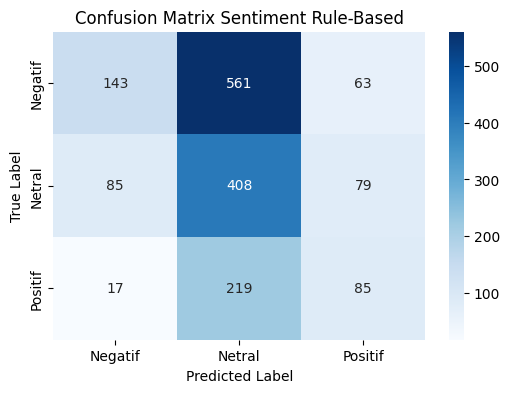

In [22]:
# =========================================================
# SENTIMENT ANALYSIS EVALUATION
# =========================================================

rule_summary_rows = []
for rule_name, col_name in applied_rule_columns:
    total_detected = int(df[col_name].sum())
    score_col = col_name.replace('_applied', '_sentiment_value')
    label_col = col_name.replace('_applied', '_sentiment_label')
    eval_df = df.loc[df[col_name]].copy()
    accuracy = (eval_df[label_col] == eval_df['true_sentiment']).mean() if total_detected > 0 else 0
    rule_summary_rows.append({
        'rule': rule_name,
        'total_detected': total_detected,
        'accuracy': round(float(accuracy), 4),
        'mean_score': round(float(eval_df[score_col].mean()), 4) if total_detected > 0 else 0,
    })

rule_summary_df = pd.DataFrame(rule_summary_rows)

# =========================================================
# EVALUASI FINAL SENTIMENT
# =========================================================

total_data = len(df)
total_correct = int((df['final_sentiment_label'] == df['true_sentiment']).sum())
total_wrong = int(total_data - total_correct)
final_accuracy = (total_correct / total_data) if total_data > 0 else 0
error_rate = (total_wrong / total_data) if total_data > 0 else 0

label_order = ['Negatif', 'Netral', 'Positif']
cm = confusion_matrix(df['true_sentiment'], df['final_sentiment_label'], labels=label_order)
final_confusion = pd.DataFrame(cm, index=label_order, columns=label_order)

print('Ringkasan evaluasi per rule:')
print(rule_summary_df.to_markdown(index=False))

print()
print('===========================================')
print('HASIL KLASIFIKASI SENTIMENT RULE-BASED')
print('===========================================')
print(f'Total Data               : {total_data}')
print(f'Prediksi Benar           : {total_correct}')
print(f'Prediksi Salah           : {total_wrong}')
print(f'Total Akurasi            : {final_accuracy:.2%}')
print(f'Error Rate               : {error_rate:.2%}')

print()
print('Confusion Matrix:')
print(final_confusion)

plt.figure(figsize=(6, 4))
sns.heatmap(final_confusion, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix Sentiment Rule-Based')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# =========================================================
# DATA MISCLASSIFIED DAN CLASSIFIED
# =========================================================

sentiment_export_columns = [
    'comment_text',
    'stemmed_normalized',
    'stemmed_sentence_1',
    'stemmed_sentence_2',
    'true_aspect_1',
    'true_aspect_2',
    'predicted_aspects_set',
    'similarity_scores',
    'true_sentiment',
    'final_sentiment_score',
    'final_sentiment_label',
    'matched_rules'
]

misclassified_sentiment_df = df.loc[
    df['final_sentiment_label'] != df['true_sentiment'],
    sentiment_export_columns
].copy()

classified_sentiment_df = df.loc[
    df['final_sentiment_label'] == df['true_sentiment'],
    sentiment_export_columns
].copy()

misclassified_sentiment_df.to_csv(
    'missclassified_sentiment.csv',
    index=False,
    encoding='utf-8-sig'
)

classified_sentiment_df.to_csv(
    'classified_sentiment.csv',
    index=False,
    encoding='utf-8-sig'
)

# =========================================================
# SIMPAN HASIL LABELING FINAL
# =========================================================

result_df = df[[
    'comment_text',
    'cleaned_text',
    'normalized_text',
    'stemmed_sentence_1',
    'stemmed_sentence_2',
    'type',
    'true_aspect_1',
    'true_aspect_2',
    'predicted_aspects',
    'similarity_scores',
    'true_sentiment',
    'final_sentiment_score',
    'final_sentiment_label',
    'matched_rules'
]].copy()

result_df.to_csv(
    'result_sentiment_analysis.csv',
    index=False,
    encoding='utf-8-sig'
)
